In [7]:
from pathlib import Path
import os

repo_root = Path(r"C:\Users\Joaquin Cerezo\Github\Vasicek_Intensity_Calibration")
os.chdir(repo_root)

processed_dir = repo_root / "data" / "processed"


# Model Inspection\n
\n
Quick sanity checks for the Vasicek risk-free factor, intensity factor, and multiplicative defaultable pricing.

## Setup

In [2]:
import numpy as np
import pandas as pd

from vasicek_poisson.models.vasicek import VasicekFactor
from vasicek_poisson.models.intensity import IntensityModel
from vasicek_poisson.pricing.bond_pricer import (
    price_zc_riskfree,
    price_zc_spread,
    price_zc_defaultable,
    yield_riskfree,
    yield_defaultable,
    credit_spread,
)


## Parameterized Example

In [3]:
rf_model = VasicekFactor(kappa=0.6, theta=0.02, sigma=0.01)
int_model = IntensityModel.from_params(kappa=0.9, theta=0.03, sigma=0.015)

r_t = 0.02
lambda_t = 0.03
maturities = np.array([0.25, 0.5, 1.0, 2.0, 5.0, 10.0])

rows = []
for T in maturities:
    p_rf = price_zc_riskfree(r_t, T, rf_model)
    p_spread = price_zc_spread(lambda_t, T, int_model)
    p_def = price_zc_defaultable(r_t, lambda_t, T, rf_model, int_model)
    y_rf = yield_riskfree(r_t, T, rf_model)
    y_def = yield_defaultable(r_t, lambda_t, T, rf_model, int_model)
    s = credit_spread(r_t, lambda_t, T, rf_model, int_model)
    rows.append((T, p_rf, p_spread, p_def, y_rf, y_def, s))

df = pd.DataFrame(
    rows,
    columns=["T", "P_rf", "P_spread", "P_def", "y_rf", "y_def", "spread"],
)
df

,T,P_rf,P_spread,P_def,y_rf,y_def,spread
0,0.25,0.995013,0.992529,0.987579,0.019999,0.049997,0.029998
1,0.50,0.990051,0.985115,0.975315,0.019997,0.049990,0.029993
2,1.00,0.980209,0.970465,0.951259,0.019989,0.049969,0.029980
3,2.00,0.960847,0.941854,0.904977,0.019970,0.049923,0.029952
4,5.00,0.905172,0.861109,0.779452,0.019926,0.049833,0.029907
5,10.00,0.819585,0.741676,0.607867,0.019896,0.049780,0.029884


## Basic Checks

In [4]:
assert np.allclose(df["P_def"], df["P_rf"] * df["P_spread"])
assert np.all(df["P_def"] <= df["P_rf"])
assert np.all(df["P_spread"] <= 1.0)

df[["T", "spread"]]

,T,spread
0,0.25,0.029998
1,0.50,0.029993
2,1.00,0.029980
3,2.00,0.029952
4,5.00,0.029907
5,10.00,0.029884


## Fit And Plot Curves\n
\n
This section loads the processed panels, fits the per-date state for risk-free and intensity, then plots observed vs. model yields.

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt

from vasicek_poisson.calibration.calibrator import (
    align_panels,
    fit_intensity_for_date,
    fit_riskfree_for_date,
)
from vasicek_poisson.calibration.objectives import yields_to_prices
from vasicek_poisson.pricing.bond_pricer import (
    price_zc_defaultable,
    price_zc_riskfree,
    price_zc_spread,
    yield_defaultable,
    yield_riskfree,
)


In [10]:
processed_dir = Path('data/processed')
aaa_path = processed_dir / 'aaa_spot_clean.csv'
all_path = processed_dir / 'all_spot_clean.csv'

if not aaa_path.exists() or not all_path.exists():
    raise FileNotFoundError(
        'Processed files not found. Run scripts/run_preprocessing.py first.'
    )

aaa_df = pd.read_csv(aaa_path)
all_df = pd.read_csv(all_path)

aaa_df['TIME_PERIOD'] = pd.to_datetime(aaa_df['TIME_PERIOD'])
all_df['TIME_PERIOD'] = pd.to_datetime(all_df['TIME_PERIOD'])

date = aaa_window['TIME_PERIOD'].max()
date

Timestamp('2020-12-30 00:00:00')

## Date Window Selection\n
\n
Use this to limit the calibration to a date range and/or a fixed number of dates.

In [9]:
# Window controls (edit as needed)
start_date = '2019-01-01'
end_date = '2020-12-31'
max_dates = 150      # cap number of dates after filtering (None = no cap)
step = 1             # subsample stride (1 = keep all)

start_date = pd.Timestamp(start_date)
end_date = pd.Timestamp(end_date)

mask = (aaa_df['TIME_PERIOD'] >= start_date) & (aaa_df['TIME_PERIOD'] <= end_date)
aaa_window = aaa_df.loc[mask].copy()
all_window = all_df.loc[mask].copy()

dates = sorted(aaa_window['TIME_PERIOD'].unique())
if step > 1:
    dates = dates[::step]
if max_dates is not None:
    dates = dates[-max_dates:]

aaa_window = aaa_window[aaa_window['TIME_PERIOD'].isin(dates)]
all_window = all_window[all_window['TIME_PERIOD'].isin(dates)]

print('Window dates:', len(dates), 'from', min(dates), 'to', max(dates))
date = max(dates)  # used for plots below
date

Window dates: 150 from 2020-06-02 00:00:00 to 2020-12-30 00:00:00


Timestamp('2020-12-30 00:00:00')

In [11]:
# Choose parameters/state: use global fit if available; otherwise use per-date fit
use_global = 'rf_global' in globals() and 'rf_states' in globals()

if use_global:
    rf_model = VasicekFactor(kappa=rf_global.kappa, theta=rf_global.theta, sigma=rf_global.sigma)
    if 'date' not in globals() or date not in set(rf_states['TIME_PERIOD']):
        date = rf_states['TIME_PERIOD'].max()
    r_t = float(rf_states.loc[rf_states['TIME_PERIOD'] == date, 'r_t'].iloc[0])
else:
    # Simple model specs for inspection (adjust as needed)
    rf_model = VasicekFactor(kappa=0.6, theta=0.02, sigma=0.01)
    rf_fit = fit_riskfree_for_date(
        aaa_df=aaa_window,
        date=date,
        model=rf_model,
        state_guess=0.02,
        state_bounds=(-0.10, 0.20),
    )
    r_t = rf_fit.r_t

r_t


RiskFreeFitResult(date=Timestamp('2020-12-30 00:00:00'), r_t=-0.04635932595735344, objective=0.07546737944695361, success=True, n_obs=358)

In [12]:
use_global_int = 'int_global' in globals() and 'int_states' in globals()

if use_global_int:
    int_model = IntensityModel.from_params(
        kappa=int_global.kappa, theta=int_global.theta, sigma=int_global.sigma
    )
    if date not in set(int_states['TIME_PERIOD']):
        date = int_states['TIME_PERIOD'].max()
    lambda_t = float(int_states.loc[int_states['TIME_PERIOD'] == date, 'lambda_t'].iloc[0])
else:
    int_model = IntensityModel.from_params(kappa=0.9, theta=0.03, sigma=0.015)
    int_fit = fit_intensity_for_date(
        aaa_df=aaa_window,
        all_df=all_window,
        date=date,
        rf_model=rf_model,
        intensity_model=int_model,
        r_t=r_t,
        state_guess=0.02,
        state_bounds=(0.0, 1.0),
    )
    lambda_t = int_fit.lambda_t

lambda_t


IntensityFitResult(date=Timestamp('2020-12-30 00:00:00'), lambda_t=5.9608609865491405e-06, objective=0.35777436334434864, success=True, n_obs=358)

In [13]:
aligned = align_panels(aaa_window, all_window, date)
T = aligned.maturities

p_rf_obs = yields_to_prices(aligned.aaa_yields, T)
p_def_obs = yields_to_prices(aligned.all_yields, T)

p_rf_model = np.array([price_zc_riskfree(r_t, t, rf_model) for t in T])
p_spread_model = np.array([price_zc_spread(lambda_t, t, int_model) for t in T])
p_def_model = np.array([
    price_zc_defaultable(r_t, lambda_t, t, rf_model, int_model)
    for t in T
])

y_rf_model = np.array([yield_riskfree(r_t, t, rf_model) for t in T])
y_def_model = np.array([yield_defaultable(r_t, lambda_t, t, rf_model, int_model) for t in T])

y_rf_obs = -np.log(p_rf_obs) / T
y_def_obs = -np.log(p_def_obs) / T

(T, y_rf_obs[:3], y_def_obs[:3])


(array([ 0.25      ,  0.33333333,  0.41666667,  0.5       ,  0.58333333,
         0.66666667,  0.75      ,  0.83333333,  0.91666667,  1.        ,
         1.08333333,  1.16666667,  1.25      ,  1.33333333,  1.41666667,
         1.5       ,  1.58333333,  1.66666667,  1.75      ,  1.83333333,
         1.91666667,  2.        ,  2.08333333,  2.16666667,  2.25      ,
         2.33333333,  2.41666667,  2.5       ,  2.58333333,  2.66666667,
         2.75      ,  2.83333333,  2.91666667,  3.        ,  3.08333333,
         3.16666667,  3.25      ,  3.33333333,  3.41666667,  3.5       ,
         3.58333333,  3.66666667,  3.75      ,  3.83333333,  3.91666667,
         4.        ,  4.08333333,  4.16666667,  4.25      ,  4.33333333,
         4.41666667,  4.5       ,  4.58333333,  4.66666667,  4.75      ,
         4.83333333,  4.91666667,  5.        ,  5.08333333,  5.16666667,
         5.25      ,  5.33333333,  5.41666667,  5.5       ,  5.58333333,
         5.66666667,  5.75      ,  5.83333333,  5.9

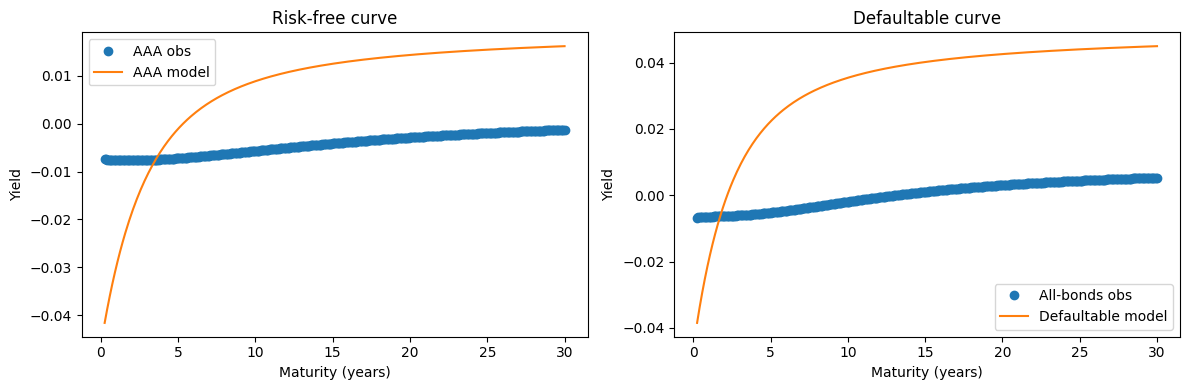

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(T, y_rf_obs, 'o', label='AAA obs')
ax[0].plot(T, y_rf_model, '-', label='AAA model')
ax[0].set_title('Risk-free curve')
ax[0].set_xlabel('Maturity (years)')
ax[0].set_ylabel('Yield')
ax[0].legend()

ax[1].plot(T, y_def_obs, 'o', label='All-bonds obs')
ax[1].plot(T, y_def_model, '-', label='Defaultable model')
ax[1].set_title('Defaultable curve')
ax[1].set_xlabel('Maturity (years)')
ax[1].set_ylabel('Yield')
ax[1].legend()

plt.tight_layout()
plt.show()

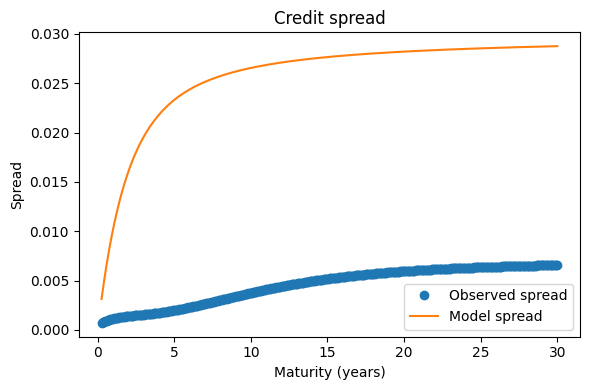

In [15]:
spread_obs = y_def_obs - y_rf_obs
spread_model = y_def_model - y_rf_model

plt.figure(figsize=(6, 4))
plt.plot(T, spread_obs, 'o', label='Observed spread')
plt.plot(T, spread_model, '-', label='Model spread')
plt.title('Credit spread')
plt.xlabel('Maturity (years)')
plt.ylabel('Spread')
plt.legend()
plt.tight_layout()
plt.show()